# 01 · 논문이 쓴 목적함수와 알고리즘이 만드는 해

## 질문과 출처

“목적함수가 명시되지 않았다”는 전제를 먼저 수정한다. [논문 §3.2.1](https://arxiv.org/html/2511.18692v1#S3.SS2.SSS1)은 **importance/latency 최대화, 선택 수 ≤ R**을 명시한다. 검토할 빈틈은 그 식의 계산 복잡도와 Algorithm 1의 예산 채우기 동작 사이에 있다. 아래 정리는 본 실험의 수학적 유도이며, 논문이 증명한 정리로 인용하지 않는다.

## 실행 준비

결과는 `runs/01_objective/`에 저장합니다. 이 셀을 다시 실행하면 해당 폴더의 이전 결과를 지우고 새로 만듭니다.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if (ROOT / "conclusion/python").is_dir():
    ROOT = ROOT / "conclusion/python"
sys.path.insert(0, str(ROOT))
import core as C
from reporting import begin, figure, finish
SEED = 20260926
RUN = begin(ROOT, "01_objective", SEED)

**결과:** `runs/01_objective/` · seed `20260926`

## 정의

채널 순서를 고정하고 $v_i\ge0$, $M\in\{0,1\}^n$로 둔다. $\mathcal R(M)$는 **최대 연속 1 구간**들의 집합이다. 후보 생성 때의 chunk 경계와 다르며, 인접한 선택 구간은 합친다.

$$
I(M)=\sum_i v_iM_i,\quad R(M)=\sum_iM_i,\quad
L_T(M)=\sum_{C\in\mathcal R(M)}T(|C|),\qquad T(\ell)>0\;(\ell\ge1).
$$

공집합에는 $I=L=0$을 주되 비율은 정의하지 않는다. 비교할 문제는 서로 다르다.

$$
\begin{aligned}
\text{Ratio}(R)&:\max_{1\le R(M)\le R}I(M)/L_T(M),\\
\text{Budget}(B)&:\max_{L_T(M)\le B} I(M),\\
\text{Coverage}(Q)&:\min_{I(M)\ge Q} L_T(M),\\
\text{Scalar}(\lambda)&:\max_M\{I(M)-\lambda L_T(M)\},\quad\lambda\ge0.
\end{aligned}
$$

고정 $R(M)=R$도 별도의 문제다. 동일한 $R$은 동일한 importance나 실제 품질을 뜻하지 않는다.

In [2]:
n, s = 14, 4
v = C.workload(n, SEED, "spiky")
cost = C.two_line(n, s)


## 정리 1 · 비율 목적은 한 구간이면 충분하다

비어 있지 않은 $M$을 최대 구간 $C_1,\ldots,C_k$로 분해하면

$$
\frac{I(M)}{L_T(M)}
=\sum_{j=1}^k\underbrace{\frac{T(|C_j|)}{\sum_hT(|C_h|)}}_{\alpha_j>0,\ \sum\alpha_j=1}
\frac{\sum_{i\in C_j}v_i}{T(|C_j|)}
\le\max_j\frac{\sum_{i\in C_j}v_i}{T(|C_j|)}.
$$

$|C_j|\le R(M)\le R$이므로 우변의 최고 구간 자체가 feasible하다. 따라서

$$
\boxed{\max_{1\le|M|\le R}\frac{I(M)}{L_T(M)}
=\max_{1\le\ell\le R}\max_{0\le a\le n-\ell}
\frac{P_{a+\ell}-P_a}{T(\ell)}},\qquad P_j=\sum_{i<j}v_i.
$$

prefix sum 이후 $O(nR)$ 시간, $O(n)$ 메모리의 정확 알고리즘이다. $2^n$개의 mask가 있다는 사실만으로 이 문제의 intractability가 증명되지는 않는다. $T$의 단조성·선형성·subadditivity조차 이 정리에 필요하지 않다. 유리수 입력에서는 덧셈·비교의 bit 비용도 다항이며 실험 코드는 float64 허용오차를 사용한다.

**범위:** 가산 run 비용, 상한형 cardinality, 비어 있지 않은 mask에 대한 정리다. $|M|=R$, $I(M)\ge Q$, mask별 고정 overhead, 병렬 I/O의 makespan이 들어가면 이 증명은 그대로 적용되지 않는다. 실제 측정 시간은 실험 07에서 별도로 다룬다.

## 재현 실험

고정 seed로 새 $v,T$를 생성한다. $n\le16$의 모든 mask와 `ratio_opt`의 최적값을 비교하고, 작은 명시적 반례를 재계산한다. 비율·retained importance·실제 선택 수를 함께 표시한다. 비율 최적해와 $R$을 채우는 방법의 importance 차이를 성능 열위로 오독하지 않는다.

검증 기준은 각 $R$에서 완전탐색과 비율 최적값이 허용오차 안에서 일치하는지다. 전역해라는 표현은 이 모델과 목적에 한정한다. 기존 실험 출력은 입력으로 읽지 않는다.

In [2]:
masks, importance, costs = C.exhaustive(v, cost)
counts = masks.sum(1)
rows = []
for r in range(1, n + 1):
    allowed = (counts > 0) & (counts <= r)
    oracle_ratio = (importance[allowed] / costs[allowed]).max()
    methods = {"Ratio exact": C.ratio_opt(v, r, cost), "Paper greedy": C.paper(v, r, cost, s)}
    for method, mask in methods.items():
        value, delay = float(v[mask].sum()), C.latency(mask, cost)
        rows.append(dict(R=r, method=method, selected=int(mask.sum()), importance=value,
                         latency=delay, ratio=value / delay, oracle_ratio=oracle_ratio))
        if method == "Ratio exact":
            assert np.isclose(value / delay, oracle_ratio)
frame = pd.DataFrame(rows)
frame.to_csv(RUN / "objectives.csv", index=False)
display(frame.loc[frame.R.isin([2, 7, 14])].round(4))

,R,method,selected,importance,latency,ratio,oracle_ratio
2,2,Ratio exact,2,15.4519,0.42,36.7903,36.7903
3,2,Paper greedy,2,15.4519,0.42,36.7903,36.7903
12,7,Ratio exact,6,31.3137,0.72,43.4912,43.4912
13,7,Paper greedy,7,38.2554,1.29,29.6554,43.4912
26,14,Ratio exact,6,31.3137,0.72,43.4912,43.4912
27,14,Paper greedy,14,42.4268,1.68,25.2540,43.4912


## 그림을 읽는 법

왼쪽의 모든 점은 $(L_T(M),I(M))$이며 원점에서 점으로 가는 직선의 기울기가 비율이다. 오른쪽은 예산 증가에 따른 **실제 선택 수**와 importance를 보여준다. 상한 $R$이 커져도 비율 최적해가 이를 채울 의무는 없다. 실행 마지막에 수치와 검증 여부를 기록한다.

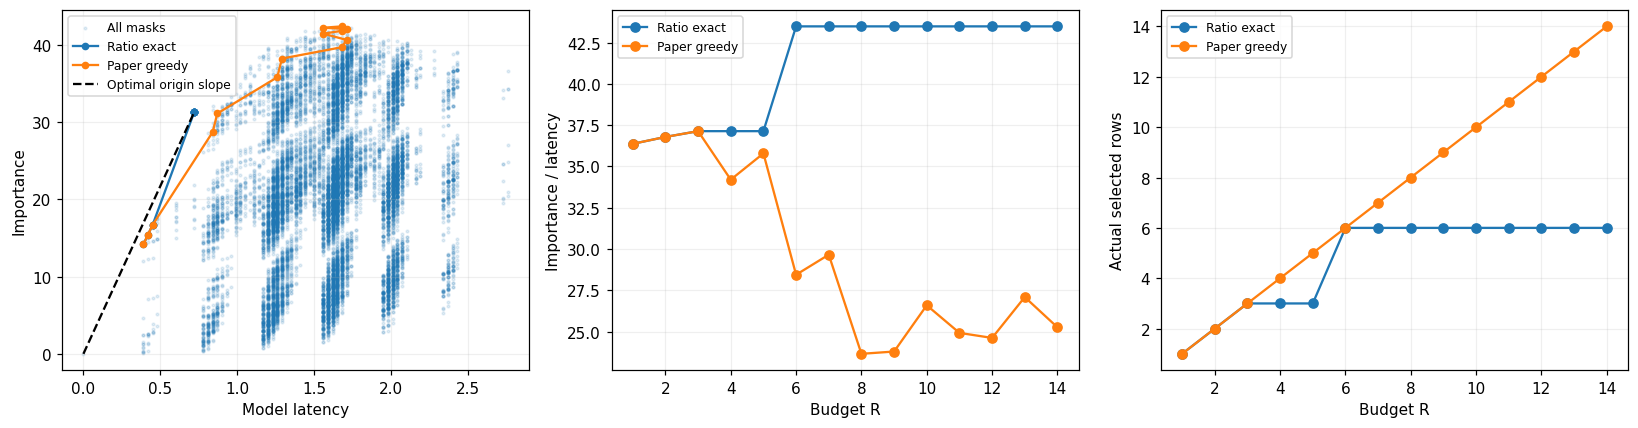

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(costs, importance, s=3, alpha=.12, label="All masks")
for method, group in frame.groupby("method", sort=False):
    axes[0].plot(group.latency, group.importance, "o-", ms=4, label=method)
    axes[1].plot(group.R, group.ratio, "o-", label=method)
    axes[2].plot(group.R, group.selected, "o-", label=method)
best = frame.query("method == 'Ratio exact'").iloc[-1]
axes[0].plot([0, best.latency], [0, best.importance], "k--", label="Optimal origin slope")
for ax, x, y in zip(axes, ["Model latency", "Budget R", "Budget R"],
                    ["Importance", "Importance / latency", "Actual selected rows"]):
    ax.set(xlabel=x, ylabel=y)
    ax.legend(fontsize=8)
figure(RUN, "ratio_and_cardinality")

## 반례 · 채우기가 비율을 낮출 수 있다

$$v=(10,0,1),\quad R=2,\quad T(\ell)=\ell.$$

가장 좋은 한 채널의 비율은 $10$. Algorithm 1의 singleton 후보를 importance 순으로 두 개 선택하면 $(1,0,1)$이고 비율은 $11/2$. 따라서 “최고 효율 chunk를 반복 선택하여 예산을 채운다”는 규칙은 논문이 적은 비율 목적의 정확 알고리즘이 아니다. 다만 후자는 더 많은 importance를 보존한다. 비율만 최적화하는 것이 품질 보존이라는 응용 목적을 충분히 표현하지 못함을 동시에 보여준다.

In [4]:
example = np.array([10., 0., 1.])
linear_cost = np.arange(4, dtype=float)
a = C.ratio_opt(example, 2, linear_cost)
b = C.paper(example, 2, linear_cost, s=1)
ratio_a = example[a].sum() / C.latency(a, linear_cost)
ratio_b = example[b].sum() / C.latency(b, linear_cost)
assert ratio_a == 10 and ratio_b == 5.5
finish(RUN, oracle_checks=n, theorem="All ratio optima matched complete enumeration",
       counterexample={"exact_ratio": ratio_a, "greedy_ratio": ratio_b,
                       "exact_mask": a.tolist(), "greedy_mask": b.tolist()},
       scope="Exact for the additive run model and |M| <= R; not a task-quality optimum")

**실행에서 확인한 값**

- **oracle_checks**: 14

- **theorem**: All ratio optima matched complete enumeration

- **counterexample**: {'exact_ratio': np.float64(10.0), 'greedy_ratio': np.float64(5.5), 'exact_mask': [True, False, False], 'greedy_mask': [True, False, True]}

- **scope**: Exact for the additive run model and |M| <= R; not a task-quality optimum